# Measuring EV Levels Inside the Shrooly Cavity

We measured the **exposure value (EV)** at the center of the Shrooly cavity as a function of **white LED brightness** using a **Sekonic L-758DR light meter**.  
The EV readings were then **converted to lux** using the formula:

\[
\text{Lux} = 2.5 \times 2^{\text{EV}}
\]

Our goal is to analyze this dataset to understand the relationship between **LED brightness**, **EV**, and **lux**, and to derive an empirical formula that maps LED brightness directly to lux.


In [5]:
%pip install pandas matplotlib seaborn scikit-learn numpy

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np

data = {
    "White LED brightness": [100, 90, 80, 70, 60, 50, 40, 30, 25, 20, 18, 15, 12, 10],
    "EV": [11.7, 11.2, 10.7, 10.2, 9.6, 8.8, 7.9, 6.9, 6.1, 5.2, 4.2, 2.1, 0.09, 0]
}



df = pd.DataFrame(data)
df["Lux"] = 2.5 * np.power(2, df["EV"])
df



,White LED brightness,EV,Lux
0,100,11.70,8317.464539
1,90,11.20,5881.335578
2,80,10.70,4158.732269
3,70,10.20,2940.667789
4,60,9.60,1940.117205
5,50,8.80,1114.304721
6,40,7.90,597.141115
7,30,6.90,298.570557
8,25,6.10,171.483754
9,20,5.20,91.895868


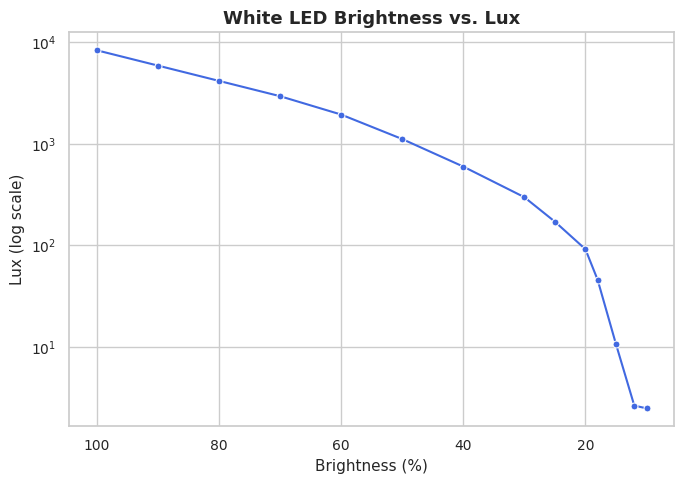

In [ ]:

import seaborn as sns
# Seaborn style

# Seaborn minimal style
sns.set_theme(style="whitegrid", context="notebook")

# Plot
plt.figure(figsize=(9,6))
sns.lineplot(
    x="White LED brightness", y="Lux", data=df,
    marker="o", markersize=10, linewidth=2.5, color="royalblue"
)

plt.yscale("log")
plt.gca().invert_xaxis()

plt.title("Original White LED Brightness vs. Lux", fontsize=18, weight="bold")
plt.xlabel("White LED Brightness (%)", fontsize=14)
plt.ylabel("Lux (log scale)", fontsize=14)

plt.show()

In [8]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
 
# Define power-law model: Lux = a * Brightness^b
def power_law(x, a, b):
    return a * np.power(x, b)

# Fit curve
popt, _ = curve_fit(power_law, df["White LED brightness"], df["Lux"])
a, b = popt

# Generate smooth fit line
x_fit = np.linspace(df["White LED brightness"].min(), df["White LED brightness"].max(), 200)
y_fit = power_law(x_fit, a, b)

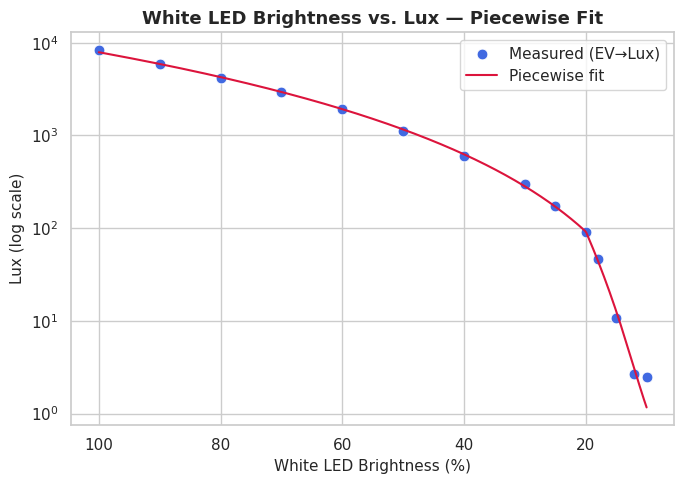

Low (≤20%): Lux ≈ 0.442 + 7.383e-08 * Brightness^6.991
High (>20%): Lux ≈ 0.02307 * Brightness^2.768
MAPE (≤20% brightness): 17.97%


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- prepare data ---
x = df["White LED brightness"].to_numpy(float)
y = df["Lux"].to_numpy(float)

# --- helper functions ---
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (MAPE), in %"""
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0

def fit_power_law(xv, yv):
    """
    Fit power-law model y = A * x^B
    Uses log–log linear regression to find A and B.
    """
    b, loga = np.polyfit(np.log(xv), np.log(yv), 1)
    return np.exp(loga), b

def predict_power_law(xv, A, B):
    """Predict y for a power-law model y = A * x^B"""
    return A * np.power(xv, B)

# --- (1) Low-end model with baseline: Lux = L0 + a * B^b ---
# Restrict fit to brightness ≤20% to capture dim region
low_mask = x <= 20
xl, yl = x[low_mask], y[low_mask]

def low_model(xv, L0, a, b):
    return L0 + a * np.power(xv, b)

# Try SciPy curve_fit; fallback to crude grid search if not available
try:
    from scipy.optimize import curve_fit
    popt, _ = curve_fit(
        low_model, xl, yl,
        p0=[yl.min()*0.8, 1e-4, 5.0],  # initial guesses
        bounds=([0.0, 1e-10, 1.0], [10.0, 1e3, 10.0]),  # parameter bounds
        maxfev=20000,
    )
    L0, a_low, b_low = popt
except Exception:
    # crude grid-search fallback
    L0_candidates = np.linspace(0.0, 10.0, 51)
    b_candidates = np.linspace(1.0, 10.0, 91)
    best = (np.inf, None)
    for L0c in L0_candidates:
        for bc in b_candidates:
            A = (xl**bc)[:, None]
            rhs = (yl - L0c)
            a_hat = max(np.linalg.lstsq(A, rhs, rcond=None)[0][0], 1e-10)
            yhat = L0c + a_hat * xl**bc
            err = mape(yl, yhat)
            if err < best[0]:
                best = (err, (L0c, a_hat, bc))
    L0, a_low, b_low = best[1]

# --- (2) Mid/High model: standard power-law for >20% brightness ---
high_mask = x > 20
A_hi, B_hi = fit_power_law(x[high_mask], y[high_mask])

# --- piecewise predictor ---
def predict_piecewise(xv):
    """Use low-end baseline model below 20%, power-law model above 20%"""
    xv = np.asarray(xv, float)
    yhat = np.empty_like(xv)
    lo = xv <= 20
    hi = ~lo
    yhat[lo] = low_model(xv[lo], L0, a_low, b_low)
    yhat[hi] = predict_power_law(xv[hi], A_hi, B_hi)
    return yhat

# --- plot using seaborn style ---
sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(7,5))
# scatter: measured points
sns.scatterplot(x=x, y=y, s=60, color="royalblue", label="Measured (EV→Lux)")
# line: fitted piecewise curve
x_fit = np.linspace(x.min(), x.max(), 400)
y_fit = predict_piecewise(x_fit)
sns.lineplot(x=x_fit, y=y_fit, color="crimson", linewidth=1.5, label="Piecewise fit")

plt.yscale("log")
plt.gca().invert_xaxis()  # show 100% brightness on the left, dimmer to the right

plt.title("White LED Brightness vs. Lux — Piecewise Fit", fontsize=13, weight="semibold")
plt.xlabel("White LED Brightness (%)", fontsize=11)
plt.ylabel("Lux (log scale)", fontsize=11)

plt.legend()
plt.tight_layout()
plt.show()

# --- report formulas & errors ---
low_pred = predict_piecewise(x[low_mask])
print(f"Low (≤20%): Lux ≈ {L0:.4g} + {a_low:.4g} * Brightness^{b_low:.4g}")
print(f"High (>20%): Lux ≈ {A_hi:.4g} * Brightness^{B_hi:.4g}")
print(f"MAPE (≤20% brightness): {mape(y[low_mask], low_pred):.2f}%")
